Notebook was used for feature engineering

setting up spark 

In [3]:
from pyspark.sql import SparkSession    
spark = SparkSession.builder \
    .appName("nyc-taxi-trip-duration-prediction") \
    .master("local[*]") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 08:41:17 WARN Utils: Your hostname, Mounis-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.16 instead (on interface en0)
26/03/20 08:41:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 08:41:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/20 08:41:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Loading the cleaned data

In [4]:
# loading the cleaned data from the folder proceessed
df_train =spark.read.csv("../data/processed/cleaned_taxi_data.csv", header=True, inferSchema=True)

In [5]:
df_train.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|        2|2016-01-01 00:09:03|              2|-73.98435974121094|40.748985290527344|-73.99628448486328| 40.71605682373047|                 N|          622|
|        1|2016-03-08 10:59:46|              1|-73.96432495117188| 40.77359390258789| -73.9897689819336| 40.73848342895508|                 N|         1324|
|        1|2016-06-04 23:43:59|              1| -73.9725570678711|40.760135650634766|-73.98609161376953|   40.762451171875|                 N|          455|
|        2|2016-03-07 19:16:34|              6|-73.9852752

Working on the pickup_datetime 

In [6]:
# crating new features from the pickup datetime column
from pyspark.sql.functions import hour, dayofmonth, month, dayofweek, weekofyear, col, when

df_train1= df_train.withColumn("pickup_hour", hour(col("pickup_datetime"))) \
    .withColumn("pickup_day", dayofmonth(col("pickup_datetime"))) \
    .withColumn("pickup_month", month(col("pickup_datetime"))) \
    .withColumn("pickup_weekday", dayofweek(col("pickup_datetime"))) \
    .withColumn("pickup_weekofyear", weekofyear(col("pickup_datetime")))


In [7]:
df_train1.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+
|        2|2016-01-01 00:09:03|              2|-73.98435974121094|40.748985290527344|-73.99628448486328| 40.71605682373047|                 N|          622|          0|         1|           1|             6|               53|
|        1|2016-03-08 10:59:46|              1|-73.96432495117188| 40.77359390258789| -73.989768

In [8]:
# creating a new feature to indicate whether the pickup day is a weekend or not
df_train1= df_train1.withColumn(
    "is_weekend",
    when(col("pickup_weekday").isin(1, 7), 1).otherwise(0)
)


In [9]:

# rush hours are typically defined as 7-9 AM and 4-7 PM, so we can create a binary feature to indicate whether a trip was made during rush hours or not.
df_train1 =df_train1.withColumn(
    "is_rush_hour",
    when(
        ((col("pickup_hour") >= 7) & (col("pickup_hour") <= 9)) |
        ((col("pickup_hour") >= 16) & (col("pickup_hour") <= 19)),
        1
    ).otherwise(0)
)
df_train1.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+
|        2|2016-01-01 00:09:03|              2|-73.98435974121094|40.748985290527344|-73.99628448486328| 40.71605682373047|                 N|          622|          0|         1|           1|             6|               53|         0|           0|


In [10]:
# night hours are typically defined as 10 PM to 5 AM, so we can create a binary feature to indicate whether a trip was made during night hours or not.
df_train1 = df_train1.withColumn(
    "is_night",
    when(
        (col("pickup_hour") >= 22) | (col("pickup_hour") <= 5),
        1
    ).otherwise(0)
)
df_train1.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+
|        2|2016-01-01 00:09:03|              2|-73.98435974121094|40.748985290527344|-73.99628448486328| 40.71605682373047|                 N|          622|          0|         1|           1|             6|               5

Creating the trip distance feature

In [11]:
# converting the pickup and dropoff latitude and longitude to radians
from pyspark.sql.functions import radians
df_distance=df_train1.withColumn("pickup_latitude_rad", radians(col("pickup_latitude")))\
    .withColumn("pickup_longitude_rad", radians(col("pickup_longitude")))\
    .withColumn("dropoff_latitude_rad", radians(col("dropoff_latitude")))\
    .withColumn("dropoff_longitude_rad", radians(col("dropoff_longitude")))

In [12]:
# calculating the differences between the pickup and dropoff lattitude and longitude
from pyspark.sql.functions import col
df_distance=df_distance.withColumn("longitude_diff_radians", col("dropoff_longitude_rad") - col("pickup_longitude_rad"))
df_distance=df_distance.withColumn("latitude_diff_radians", col("dropoff_latitude_rad") - col("pickup_latitude_rad"))

In [13]:
df_distance.printSchema()

root
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- trip_duration: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- pickup_weekofyear: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- is_rush_hour: integer (nullable = false)
 |-- is_night: integer (nullable = false)
 |-- pickup_latitude_rad: double (nullable = true)
 |-- pickup_longitude_rad: double (nullable = true)
 |-- dropoff_latitude_rad: double (nullable = true)
 |-- dropoff_longitude_rad: double (nullable = true

In [14]:
# calculating the distance between the pickup and dropoff locations using the Haversine formula
from pyspark.sql.functions import sqrt, sin, cos, asin
from pyspark.sql.functions import col
radius=6371 # radius of the Earth in kilometers
df_distance=df_distance.withColumn("trip_distance_km",2*radius*asin(sqrt(sin(col("latitude_diff_radians")/2)**2+cos(col("pickup_latitude_rad"))*cos(col("dropoff_latitude_rad"))*sin(col("longitude_diff_radians")/2)**2)))

In [15]:
df_distance.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+-------------------+--------------------+--------------------+---------------------+----------------------+---------------------+------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|pickup_latitude_rad|pickup_longitude_rad|dropoff_latitude_rad|dropoff_longitude_rad|longitude_diff_radians|latitude_diff_radians|  trip_distance_km|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+-------

In [16]:
df_distance.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+-------------------+--------------------+--------------------+---------------------+----------------------+---------------------+------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|pickup_latitude_rad|pickup_longitude_rad|dropoff_latitude_rad|dropoff_longitude_rad|longitude_diff_radians|latitude_diff_radians|  trip_distance_km|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+-------

In [17]:
df_distance.select("trip_distance_km").describe().show()

+-------+------------------+
|summary|  trip_distance_km|
+-------+------------------+
|  count|           1447731|
|   mean|3.4532784721903877|
| stddev| 3.940626016671512|
|    min|               0.0|
|    max| 93.49514559204533|
+-------+------------------+



In [18]:
# comparing the trip distance and the trip duration
from pyspark.sql.functions import  col,corr
df_distance.select(corr(col("trip_distance_km"), col("trip_duration"))).show()

+-------------------------------------+
|corr(trip_distance_km, trip_duration)|
+-------------------------------------+
|                   0.7692903771981949|
+-------------------------------------+



Create Direction Feature 

In [19]:
from pyspark.sql.functions import col, radians, sin,cos,atan2
feature_engineering_df=df_distance.withColumn(
    "direction",
    atan2(
        sin(col("longitude_diff_radians")) * cos(col("dropoff_latitude_rad")),
        cos(col("pickup_latitude_rad"))*sin(col("dropoff_latitude_rad"))-
        sin(col("pickup_latitude_rad"))*cos(col("dropoff_latitude_rad"))*
        cos(col("longitude_diff_radians"))
    )
)

In [20]:
feature_engineering_df.select("direction").show(5)

+-------------------+
|          direction|
+-------------------+
|-2.8737003042455274|
| -2.639413998745596|
|-1.3485766427091899|
| 3.0563141530311357|
|-0.7344506861562125|
+-------------------+
only showing top 5 rows


In [21]:
feature_engineering_df.select("direction").describe().show()

+-------+-------------------+
|summary|          direction|
+-------+-------------------+
|  count|            1447731|
|   mean|-0.2743963765976185|
| stddev| 1.8248472769485242|
|    min|-3.1414652585380134|
|    max|  3.141592653589793|
+-------+-------------------+



Coordinates difference of latitude and longitide

In [22]:
from pyspark.sql.functions import col
feature_engineering_df=feature_engineering_df.withColumn("latitude_difference", col("dropoff_latitude") - col("pickup_latitude"))
feature_engineering_df=feature_engineering_df.withColumn("longitude_difference", col("dropoff_longitude") - col("pickup_longitude"))




In [23]:
feature_engineering_df.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+-------------------+--------------------+--------------------+---------------------+----------------------+---------------------+------------------+-------------------+--------------------+--------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|pickup_latitude_rad|pickup_longitude_rad|dropoff_latitude_rad|dropoff_longitude_rad|longitude_diff_radians|latitude_diff_radians|  trip_distance_km|          direction| latitude_difference|longitude_difference|
+---------+-------------------+---------------+---------------

26/03/20 08:41:25 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Categorical variables encoding 

In [24]:
feature_df=feature_engineering_df.drop("pickup_latitude_rad", "pickup_longitude_rad", "dropoff_latitude_rad", "dropoff_longitude_rad", "longitude_diff_radians", "latitude_diff_radians")

In [25]:
feature_df.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--

In [26]:
# finding the unique values in the vendor_id and store_and_fwd_flag columns
feature_df.select("vendor_id").distinct().show()    
feature_df.select("store_and_fwd_flag").distinct().show()    

+---------+
|vendor_id|
+---------+
|        1|
|        2|
+---------+

+------------------+
|store_and_fwd_flag|
+------------------+
|                 Y|
|                 N|
+------------------+



In [27]:
feature_df.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--

In [28]:
#encoding the categorical features using StringIndexer
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline
cols_to_index=["vendor_id", "store_and_fwd_flag"]
indexers=[StringIndexer(inputCol=col, outputCol=col+"_index").fit(feature_df) for col in cols_to_index]
pipeline=Pipeline(stages=indexers)
indexed_df=pipeline.fit(feature_df).transform(feature_df)
indexed_df.show(5)


+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+---------------+------------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|vendor_id_index|store_and_fwd_flag_index|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+--

In [29]:
# encoding the categorical features using OneHotEncoder
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml import Pipeline
encoder=OneHotEncoder(inputCols= ["vendor_id_index", "store_and_fwd_flag_index"], outputCols=["vendor_id_encoded", "store_and_fwd_flag_encoded"])
pipeline=Pipeline(stages=[encoder])
encoded_df=pipeline.fit(indexed_df).transform(indexed_df)
encoded_df.show(5)

+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+-----------+----------+------------+--------------+-----------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+---------------+------------------------+-----------------+--------------------------+
|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_hour|pickup_day|pickup_month|pickup_weekday|pickup_weekofyear|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|vendor_id_index|store_and_fwd_flag_index|vendor_id_encoded|store_and_fwd_flag_encoded|
+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+------

In [30]:
encoded_df.printSchema()

root
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- trip_duration: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- pickup_weekofyear: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- is_rush_hour: integer (nullable = false)
 |-- is_night: integer (nullable = false)
 |-- trip_distance_km: double (nullable = true)
 |-- direction: double (nullable = true)
 |-- latitude_difference: double (nullable = true)
 |-- longitude_difference: double (nullable = true)
 |-- vendor_id

In [31]:
# dropping the columns that are not needed for modeling
final_df=encoded_df.drop('vendor_id','pickup_datetime','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude', 'store_and_fwd_flag','pickup_day','pickup_weekofyear', 'vendor_id_index', 'store_and_fwd_flag_index')

In [32]:
final_df.show(5)

+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+
|passenger_count|trip_duration|pickup_hour|pickup_month|pickup_weekday|is_weekend|is_rush_hour|is_night|  trip_distance_km|          direction| latitude_difference|longitude_difference|vendor_id_encoded|store_and_fwd_flag_encoded|
+---------------+-------------+-----------+------------+--------------+----------+------------+--------+------------------+-------------------+--------------------+--------------------+-----------------+--------------------------+
|              2|          622|          0|           1|             6|         0|           0|       1|3.7968399392402117|-2.8737003042455274|  -0.032928466796875|-0.01192474365234375|    (1,[0],[1.0])|             (1,[0],[1.0])|
|              1|         1324|         10|           3|             3|     

In [33]:
final_df.printSchema()

root
 |-- passenger_count: integer (nullable = true)
 |-- trip_duration: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- is_rush_hour: integer (nullable = false)
 |-- is_night: integer (nullable = false)
 |-- trip_distance_km: double (nullable = true)
 |-- direction: double (nullable = true)
 |-- latitude_difference: double (nullable = true)
 |-- longitude_difference: double (nullable = true)
 |-- vendor_id_encoded: vector (nullable = true)
 |-- store_and_fwd_flag_encoded: vector (nullable = true)



In [34]:
# checking for missing values in the final dataframe
from pyspark.sql.functions import col, count,when
final_df.select([count(when(col(c).isNull(),c)).alias(c) for c in final_df.columns]).show()

+---------------+-------------+-----------+------------+--------------+----------+------------+--------+----------------+---------+-------------------+--------------------+-----------------+--------------------------+
|passenger_count|trip_duration|pickup_hour|pickup_month|pickup_weekday|is_weekend|is_rush_hour|is_night|trip_distance_km|direction|latitude_difference|longitude_difference|vendor_id_encoded|store_and_fwd_flag_encoded|
+---------------+-------------+-----------+------------+--------------+----------+------------+--------+----------------+---------+-------------------+--------------------+-----------------+--------------------------+
|              0|            0|          0|           0|             0|         0|           0|       0|               0|        0|                  0|                   0|                0|                         0|
+---------------+-------------+-----------+------------+--------------+----------+------------+--------+----------------+-------

In [35]:
numeric_df = final_df.select(
    "trip_duration",
    "passenger_count",
    "pickup_hour",
    "pickup_month",
    "pickup_weekday",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "trip_distance_km",
    "latitude_difference",
    "longitude_difference",
    "direction"
)

In [37]:
sample_df = numeric_df.sample(False, 0.1, seed=42).toPandas()

In [38]:
corr_matrix = sample_df.corr()

In [39]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


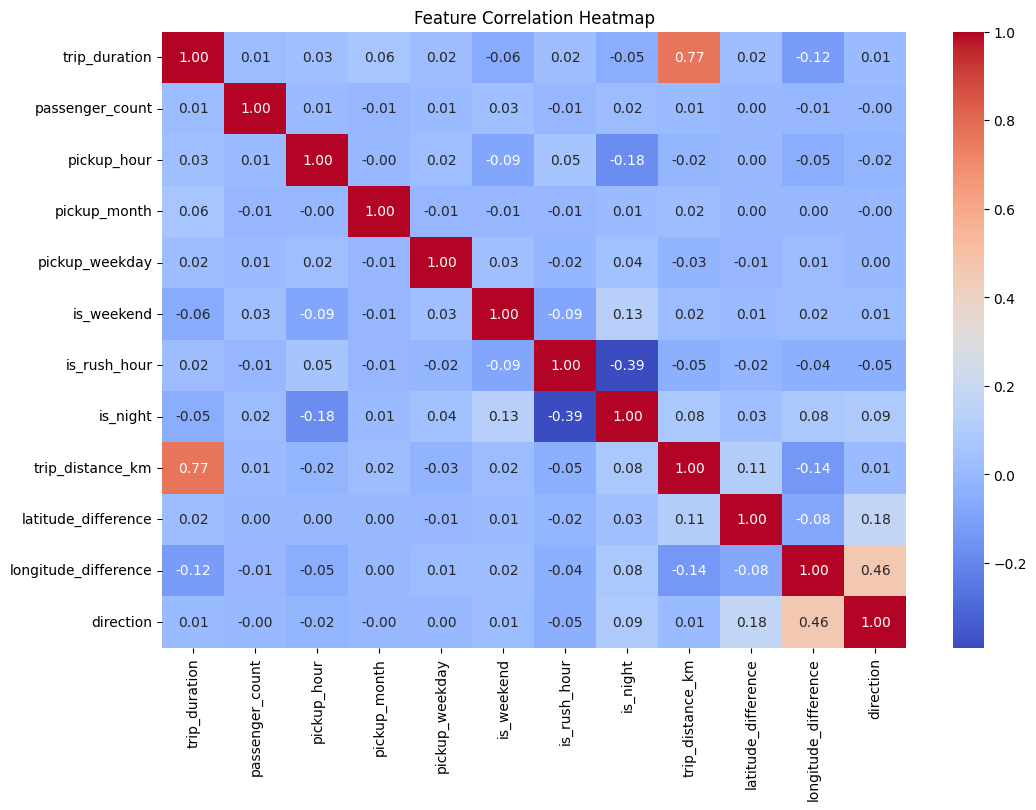

26/03/20 21:41:25 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 929256 ms exceeds timeout 120000 ms
26/03/20 21:41:25 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/20 21:41:32 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

Saving the data after doing the feature engineering


In [36]:
final_df.write.mode("overwrite").option("header", "true").parquet("../data/final_data/final_taxi_data.Parquet")

26/03/20 08:41:29 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
